In [3]:
# Customer Churn Prediction Using Machine Learning

'''This project aims to predict whether a telecom customer is likely to leave the company based on customer demographics,
account information, and service usage patterns.'''

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Telco-Customer-Churn.csv")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.shape

(7043, 21)

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [9]:
df.loc[533]

customerID                       1297-VQDRP
gender                                 Male
SeniorCitizen                             1
Partner                                 Yes
Dependents                              Yes
tenure                                   68
PhoneService                            Yes
MultipleLines                           Yes
InternetService                 Fiber optic
OnlineSecurity                           No
OnlineBackup                             No
DeviceProtection                        Yes
TechSupport                             Yes
StreamingTV                             Yes
StreamingMovies                         Yes
Contract                           One year
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                       107.15
TotalCharges                         7379.8
Churn                                    No
Name: 533, dtype: object

In [10]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [12]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [13]:
df['TotalCharges'].fillna(df['TotalCharges'].median,inplace=True)
df['TotalCharges'].isna().sum()

/tmp/ipykernel_39980/2538468077.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<bound method Series.median of 0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64>' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['TotalCharges'].fillna(df['TotalCharges'].median,inplace=True)


np.int64(0)

In [14]:
df['TotalCharges'].isna().sum()

np.int64(0)

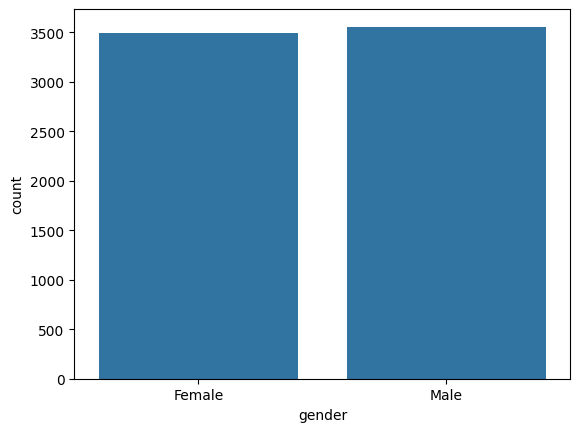

In [15]:
sns.countplot(x='gender',data=df)
plt.show()

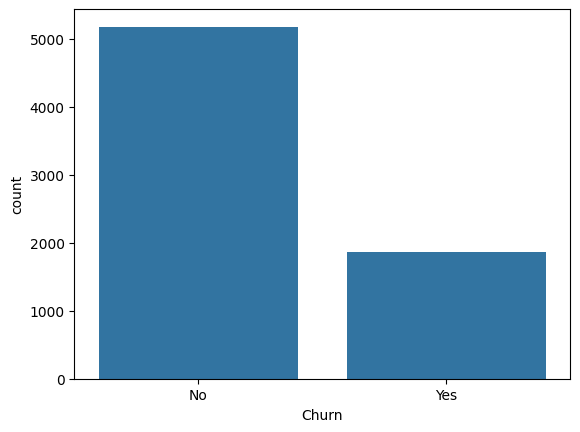

In [16]:
sns.countplot(x='Churn',data=df)
plt.show()

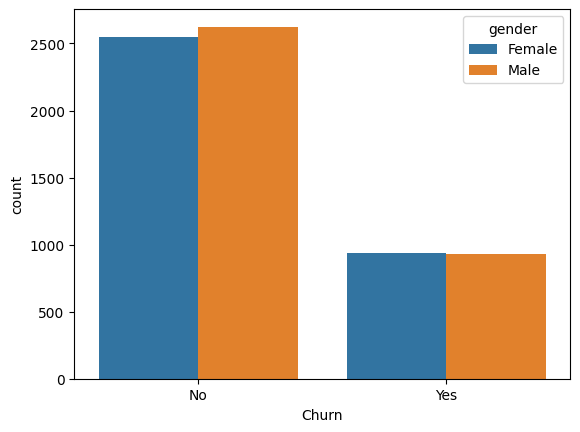

In [17]:
sns.countplot(x='Churn',hue='gender',data=df)
plt.show()

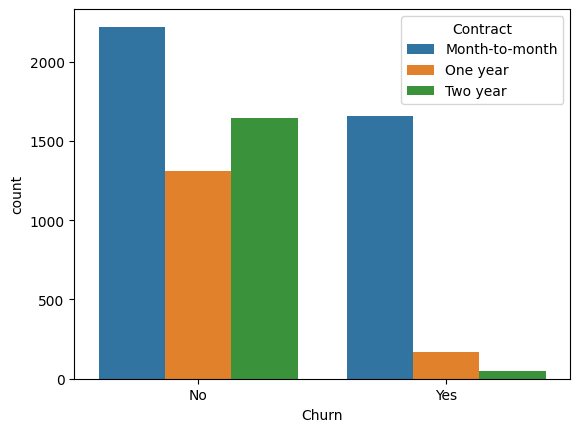

In [18]:
sns.countplot(x='Churn',hue='Contract',data=df)
plt.show()

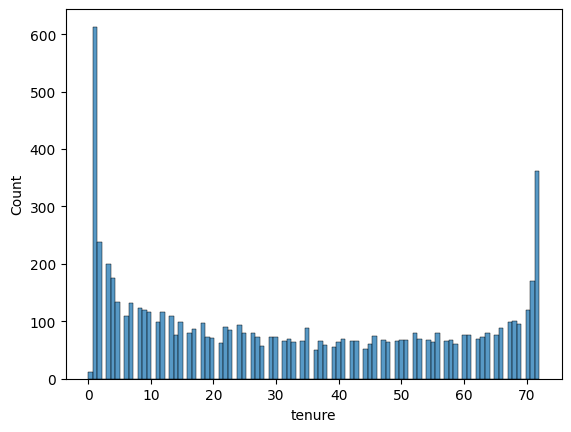

In [19]:
sns.histplot(df['tenure'],bins=100)
plt.show()

In [20]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<Axes: xlabel='Churn', ylabel='count'>

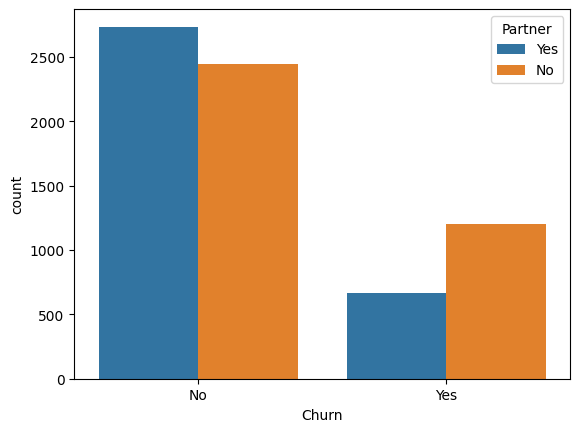

In [21]:
sns.countplot(x='Churn',hue='Partner',data=df)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

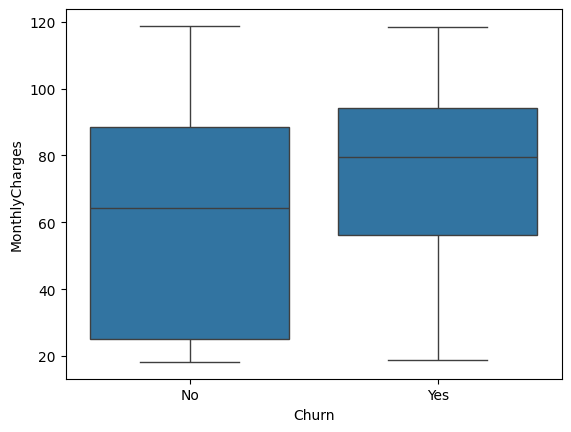

In [23]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

In [24]:
df["tenure"].skew()

np.float64(0.2395397495619829)

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

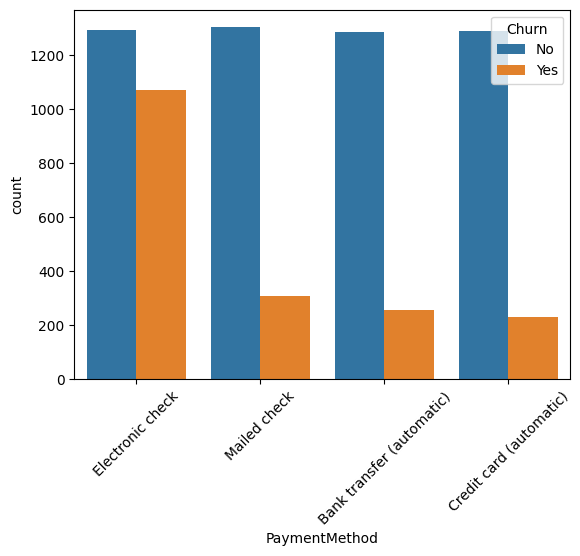

In [25]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)

<Axes: xlabel='Contract', ylabel='count'>

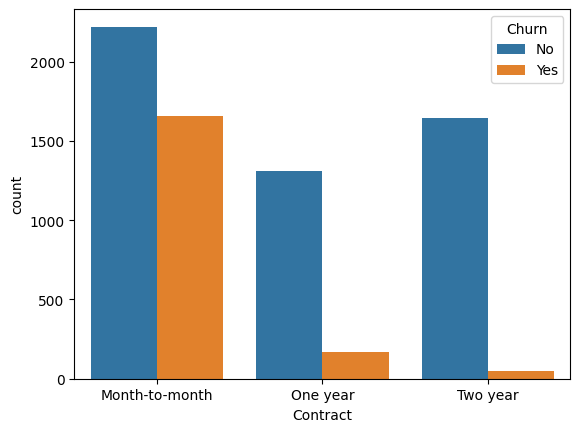

In [26]:
sns.countplot(x="Contract", hue="Churn", data=df)

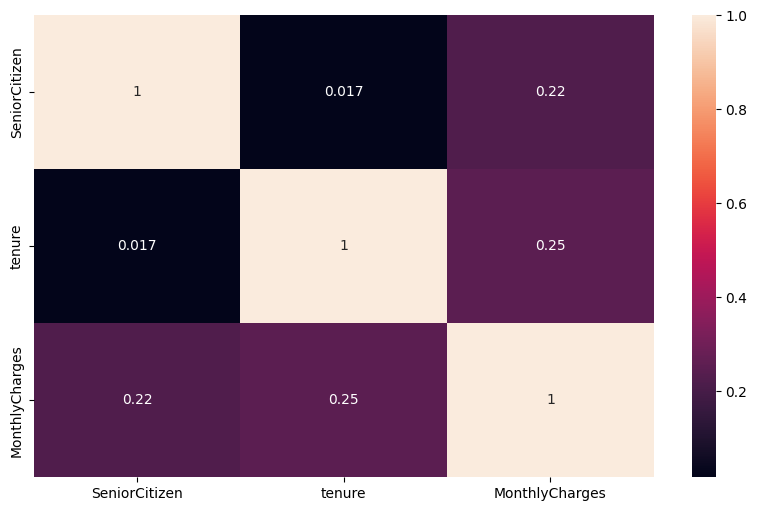

In [27]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [28]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df=df.drop('customerID',axis=1)
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})


In [32]:
df['Churn'].head(5)

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [33]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [34]:
cat_cols=X.select_dtypes(include='object').columns
num_cols=X.select_dtypes(exclude='object').columns

In [41]:
X=pd.get_dummies(X,drop_first=True)

In [42]:
X

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_2625.25,TotalCharges_6886.25,TotalCharges_1495.1,TotalCharges_743.3,TotalCharges_1419.4,TotalCharges_1990.5,TotalCharges_7362.9,TotalCharges_346.45,TotalCharges_306.6,TotalCharges_6844.5
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,True,True,True,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
7039,0,72,103.20,False,True,True,True,False,True,True,...,False,False,False,False,False,False,True,False,False,False
7040,0,11,29.60,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
7041,1,4,74.40,True,True,False,True,False,True,True,...,False,False,False,False,False,False,False,False,True,False


In [43]:
from sklearn.model_selection import train_test_split
X_train,y_train,X_test,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [45]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [46]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
X = pd.get_dummies(X, drop_first=True)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [47]:
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [53]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [55]:
y_pred=lr.predict(X_test)

In [58]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred)

# Print Metrics
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy : 0.794180269694819
Precision: 0.63125
Recall   : 0.5401069518716578
F1 Score : 0.5821325648414986
ROC-AUC  : 0.7130486450179544

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409


Confusion Matrix:

[[917 118]
 [172 202]]


In [59]:
y_prob = lr.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8404479578392623

ROC-AUC Score: 0.8404479578392623


In [60]:
#Decision Trees


In [64]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)

In [65]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)


f1 = f1_score(y_test, y_pred)


roc_auc = roc_auc_score(y_test, y_pred)

# Print Metrics
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy : 0.7629524485450674
Precision: 0.5613496932515337
Recall   : 0.4893048128342246
F1 Score : 0.5228571428571429
ROC-AUC  : 0.6755702808132475

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1035
           1       0.56      0.49      0.52       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.75      0.76      0.76      1409


Confusion Matrix:

[[892 143]
 [191 183]]


In [67]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

Accuracy : 0.7984386089425124
Precision: 0.67578125
Recall   : 0.4625668449197861
F1 Score : 0.5492063492063493
ROC-AUC  : 0.8204913585987754


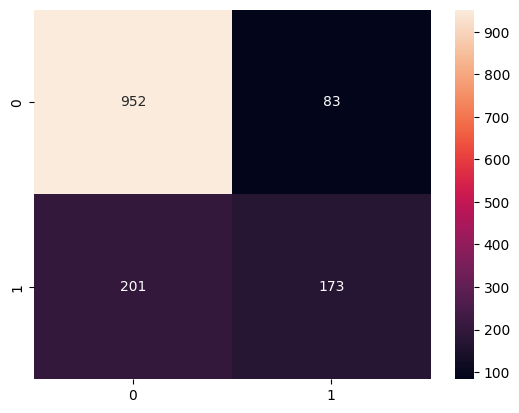

In [68]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("Precision:", precision_score(y_test, y_pred_rf))

print("Recall   :", recall_score(y_test, y_pred_rf))

print("F1 Score :", f1_score(y_test, y_pred_rf))

print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.show()

Accuracy : 0.7267565649396736
Precision: 0.4913657770800628
Recall   : 0.8368983957219251
F1 Score : 0.619188921859545
ROC-AUC  : 0.8416621457542173

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1035
           1       0.49      0.84      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.70      1409
weighted avg       0.81      0.73      0.74      1409


Confusion Matrix:

[[711 324]
 [ 61 313]]


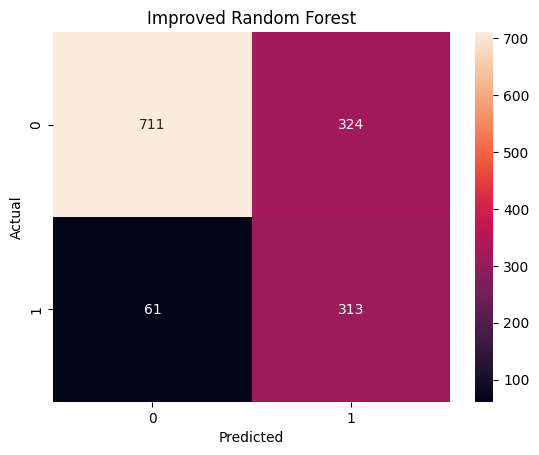

In [78]:

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced_subsample',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]


threshold = 0.35

y_pred_rf = (y_prob_rf >= threshold).astype(int)


print("Accuracy :",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall   :",
      recall_score(y_test, y_pred_rf))

print("F1 Score :",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_rf
))

# Confusion Matrix
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("\nConfusion Matrix:\n")
print(cm_rf)

# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_rf, annot=True, fmt='d')

plt.title("Improved Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [79]:
import os
import joblib

# Create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained model
joblib.dump(rf, "models/churn_random_forest.pkl")

# Save the scaler
joblib.dump(scaler, "models/scaler.pkl")

# Save the trained feature columns
joblib.dump(X.columns.tolist(), "models/model_columns.pkl")

# Save your chosen threshold
joblib.dump(0.35, "models/threshold.pkl")

print("Model and related files saved successfully.")

Model and related files saved successfully.


In [80]:
def predict_churn(new_data):
    import joblib
    import pandas as pd
    import numpy as np

    # Load saved files
    model = joblib.load("models/churn_random_forest.pkl")
    scaler = joblib.load("models/scaler.pkl")
    model_columns = joblib.load("models/model_columns.pkl")
    threshold = joblib.load("models/threshold.pkl")

    # Make copy
    df_new = new_data.copy()

    # Convert TotalCharges if needed
    if "TotalCharges" in df_new.columns:
        df_new["TotalCharges"] = pd.to_numeric(df_new["TotalCharges"], errors="coerce")
        df_new["TotalCharges"] = df_new["TotalCharges"].fillna(df_new["TotalCharges"].median())

    # One-hot encode
    df_new = pd.get_dummies(df_new, drop_first=True)

    # Align columns with training data
    df_new = df_new.reindex(columns=model_columns, fill_value=0)

    # Scale numeric columns
    num_cols = [col for col in ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"] if col in df_new.columns]
    df_new[num_cols] = scaler.transform(df_new[num_cols])

    # Predict probability and class
    prob = model.predict_proba(df_new)[:, 1]
    pred = (prob >= threshold).astype(int)

    return pred, prob

Note: you may need to restart the kernel to use updated packages.
